In [34]:
from typing import Any, List, Optional, Callable, Sequence, Tuple, Union, Literal
from jaxtyping import Array, Float, Int, PyTree # https://github.com/google/jaxtyping
from jax.random import PRNGKey

import dataclasses

import matplotlib.pyplot as plt
from tqdm import tqdm

import jax
import jax.numpy as jnp
import numpy as np
import math
import distrax
print("Distrax version:", distrax.__version__)
import flax
from flax import nnx
print("Flax version:", flax.__version__)
import optax
print("Optax version:", optax.__version__)
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
print("Torch version:", torch.__version__)

Distrax version: 0.1.8
Flax version: 0.12.7
Optax version: 0.2.8
Torch version: 2.12.0


In [ ]:
from distrax._src.bijectors.masked_coupling import MaskedCoupling
from distrax._src.bijectors.inverse import Inverse
from distrax._src.bijectors.chain import Chain
from distrax._src.distributions.transformed import Transformed
from math import prod

class MLP(nnx.Module):
    def __init__(self,
                 layer_dims: Sequence[tuple],
                 activation: Callable = nnx.leaky_relu,
                 use_bias: bool = True,
                 rngs: nnx.Rngs = nnx.Rngs(0),
                 kernel_init: Callable = nnx.initializers.lecun_normal
                 ):
                 
        assert len(layer_dims)>0, "At least one layer dimension must be specified in layer_dims."
        self.activation = activation
        self.layer_dims = tuple(tuple(x) if not isinstance(x, tuple) else x for x in layer_dims)
        self.layers = nnx.List()
        for layer_dim in layer_dims:
            self.layers.append(nnx.Linear(layer_dim[0], 
                                          layer_dim[1], 
                                          rngs=rngs, 
                                          use_bias=use_bias, 
                                          kernel_init=kernel_init
                                          )
                                )
    def __call__(self, x):
        for l, layer in enumerate(self.layers[:-1]):
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x
        

class Conditioner(nnx.Module):
    def __init__(self,
                 features_shape: tuple,
                 context_shape: tuple,
                 hidden_dims: Sequence[tuple],
                 num_bijector_params: int,
                 activation: Callable = nnx.leaky_relu,
                 rngs: nnx.Rngs = nnx.Rngs(0),
                 kernel_init: Callable = nnx.initializers.lecun_normal(),
                 ):
        self.features_shape = features_shape
        self.context_shape = context_shape
        self.num_bijector_params = num_bijector_params
        self.activation = activation

        self.n_flat_features = jax.tree.reduce(lambda carry, x: carry*x, features_shape)
        self.n_flat_context = jax.tree.reduce(lambda carry, x: carry*x, context_shape)
        self.layer_dims = ((self.n_flat_features+self.n_flat_context, hidden_dims[0][0]),) + hidden_dims

        self._conditioner = nnx.List()
        self._conditioner_mlp = MLP(self.layer_dims, activation, rngs=rngs, kernel_init=kernel_init) # Build the NN as specified by layer_dims that learns the sline transformation parameters
        self._conditioner_out = nnx.Linear(self.layer_dims[-1][-1],
                                            self.n_flat_features*num_bijector_params,
                                            rngs=rngs,
                                            kernel_init=kernel_init
                                            )
    
    def __call__(self, x, context=None):
        # Flatten feature vector to prepare for parsing into spline transform Conditioner, which is a multilayer perceptron
        x_batch_shape = x.shape[:-len(self.features_shape)]
        x = x.reshape(*x_batch_shape, -1)

        if context is not None:
            # Stack the flattened context vector to the flattened feature vector for the Conditioner in a conditional flow transform
            context_batch_shape = context.shape[:-len(self.context_shape)]
            assert x_batch_shape == context_batch_shape, f"Batch shape mismatch: features (x) has shape {x_batch_shape}, context has shape {context_batch_shape}"
            context = context.reshape(*context_batch_shape, -1)
            x = jnp.hstack([context,x])

        x = self._conditioner_mlp(x)
        x = self.activation(x)
        x = self._conditioner_out(x)
        x = x.reshape(*x_batch_shape, *(self.features_shape + (self.num_bijector_params,)))
        return x


class ConditionalInverse(Inverse):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def forward(self, x: Array, context: Optional[Array] = None) -> Array:
        return self._bijector.inverse(x, context)

    def inverse(self, y: Array, context: Optional[Array] = None) -> Array:
        return self._bijector.forward(y, context)

    def forward_and_log_det(self, x: Array, context: Optional[Array] = None) -> Tuple[Array, Array]:
        return self._bijector.inverse_and_log_det(x, context)

    def inverse_and_log_det(self, y: Array, context: Optional[Array] = None) -> Tuple[Array, Array]:
        return self._bijector.forward_and_log_det(y, context)


``
class ConditionalMaskedCoupling(MaskedCoupling):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def forward(self, x: Array, context: Optional[Array] = None) -> Array:
        y, _ = self.forward_and_log_det(x, context=context)
        return y

    def inverse(self, y: Array, context: Optional[Array] = None) -> Array:
        x, _ = self.inverse_and_log_det(y, context=context)
        return x

    def forward_and_log_det(self, x: Array, context: Optional[Array] = None) -> Tuple[Array, Array]:
        self._check_forward_input_shape(x)
        masked_x = jnp.where(self._event_mask, x, 0.0)
        params = self._conditioner(masked_x, context)
        y0, log_d = self._inner_bijector(params).forward_and_log_det(x)
        y = jnp.where(self._event_mask, x ,y0)
        # logdet = math.sum_last(
        #     jnp.where(self._mask, 0., log_d),
        #     self._event_ndims - self._inner_event_ndims
        # )
        # Or sum log-det Jacobian over event dimensions, robust to N-D feature(event) dimensions
        event_dims = tuple(range(-self._event_ndims, 0)) if self._event_ndims > 0 else ()
        logdet = jnp.sum(
            jnp.where(self._mask, 0., log_d),
            axis=event_dims
        )
        return y, logdet

    def inverse_and_log_det(self, y: Array, context: Optional[Array] = None) -> Tuple[Array, Array]:
        self._check_inverse_input_shape(y)
        masked_y = jnp.where(self._event_mask, y, 0.0)
        params = self._conditioner(masked_y, context)
        x0, log_d = self._inner_bijector(params).inverse_and_log_det(y)
        x = jnp.where(self._event_mask, y, x0)
        # logdet = math.sum_last(
        #     jnp.where(self._event_mask, 0., log_d),
        #     self._event_ndims - self._inner_event_ndims
        # )
        # Or sum log-det Jacobian over event dimensions, robust to N-D feature(event) dimensions
        event_dims = tuple(range(-self._event_ndims, 0)) if self._event_ndims > 0 else ()
        logdet = jnp.sum(
            jnp.where(self._mask, 0., log_d),
            axis=event_dims
        )
        return x, logdet


class ConditionalChain(Chain):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def forward(self, x: Array, context: Optional[Array] = None) -> Array:
        for bijector in reversed(self._bijectors):
            x = bijector.forward(x, context)
        return x

    def inverse(self, y: Array, context: Optional[Array] = None) -> Array:
        for bijector in self._bijectors:
            y = bijector.inverse(y, context)
        return y

    def forward_and_log_det(self, x: Array, context: Optional[Array] = None) -> Tuple[Array, Array]:
        x, log_det = self._bijectors[-1].forward_and_log_det(x, context)
        for bijector in reversed(self._bijectors[:-1]):
            x, ld = bijector.forward_and_log_det(x, context)
            log_det += ld
        return x, log_det

    def inverse_and_log_det(self, y: Array, context: Optional[Array] = None) -> Tuple[Array, Array]:
        y, log_det = self._bijectors[0].inverse_and_log_det(y, context)
        for bijector in self._bijectors[1:]:
            y, ld = bijector.inverse_and_log_det(y, context)
            log_det += ld
        return y, log_det


class ConditionalTransformed(Transformed):
    def __init__(self, distribution, flow):
        super().__init__(distribution, flow)

    def log_prob(self, y: Array, context: Optional[Array] = None) -> Array:
        """See `Distribution.log_prob`."""
        x, ildj_y = self.bijector.inverse_and_log_det(y, context=context)
        lp_x = self.distribution.log_prob(x)
        lp_y = lp_x + ildj_y
        return lp_y

    def sample(self, seed: Union[int, PRNGKey], sample_shape: Tuple[int], context: Optional[Array] = None) -> Array:
        x = self.distribution.sample(seed=seed, sample_shape=sample_shape)
        y, _ = self.bijector.forward_and_log_det(x, context)
        return y

    def sample_and_log_prob(self, seed: PRNGKey, sample_shape: List[int], context: Optional[Array] = None) -> Tuple[Array, Array]:
        x, lp_x = self.distribution.sample_and_log_prob(seed=seed, sample_shape=sample_shape)
        y, fldj = jax.vmap(self.bijector.forward_and_log_det)(x, context)
        lp_y = jax.vmap(jnp.subtract)(lp_x, fldj)
        return y, lp_y

    

class RQSplineFlow(nnx.Module):
    # Needed to make sure that non-nnx.Module objects from distrax are tracked by nnx
    # Alternative implementation is to use nnx.data(...) in the actual code and call on the 
    conditioners: nnx.List[Conditioner]
    transforms: nnx.Data[list]
    inverse_bijector: nnx.Data[ConditionalInverse]
    base_dist: nnx.Data[distrax.Distribution]
    inverse_flow: nnx.Data[ConditionalTransformed]

    def __init__(self,
                 n_features: int,
                 n_context: int = 0,
                 n_transforms: int = 4,
                 hidden_dims: tuple = ((32,32), (32,32)),
                 activation: str = "gelu",
                 n_bins: int = 8,
                 range_min: float = -1.0,
                 range_max: float = 1.0,
                 bijector_type: Callable = distrax.RationalQuadraticSpline,
                 ):
        
        self.features_shape = (n_features, )
        self.context_shape = (n_context, )
        self.n_bins = n_bins
        self.range_min = range_min
        self.range_max = range_max
        self.num_bijector_params = 3*self.n_bins + 1
        self.bijector_type = bijector_type
        self.n_transforms = n_transforms # Number of conditioner-bijector layers in the overall flow

        # Bijector transformation used in each layer of the flow
        # bijector_fn currently defined only for distrax.RationalQuadraticSpline
        def bijector_fn(params: Array):
            return self.bijector_type(params, self.range_min, self.range_max)
        self.bijector_fn = bijector_fn

        # Instantiate all the conditioners needed for #n_transform RQSpline transforms
        self.hidden_dims = hidden_dims
        self.conditioners = nnx.List() # Use nnx.List such that nnx knows to track the conditioner nnx modules
        for t in range(self.n_transforms):
            self.conditioners.append(
                Conditioner(self.features_shape, self.context_shape, self.hidden_dims, self.num_bijector_params)
            )

    # def make_flow(self):
        """
        Make distrax distribution containing the rational quadratic spline flow.

        Returns:
            Base Gaussian transformed by rational quadratic spline flow.
        """
        # First create alternating binary mask for the masked coupling mechanism 
        mask = jnp.arange(0, np.prod(self.features_shape)) % 2
        mask = jnp.reshape(mask, self.features_shape)
        self.mask = mask.astype(bool)

        # Now instantiate all the coupling trandforms
        # self.transforms = []
        # for t in range(self.n_transforms):
        #     self.transforms.append(
        #         ConditionalMaskedCoupling(mask=mask, bijector=self.bijector_fn, conditioner=self.conditioners[t])
        #         )
        #     mask = jnp.logical_not(mask) # Flipping the binary mask on the input features to the conditioner for each coupling transform
        # # self.transforms = nnx.data(self.transforms)

        # Now stack all transforms as single distrax.bjector child class 
        # Note that the convention used here is such that the RQSpline transforms map from data features to the conditional context,
        # We need to invert it for probability evaluation
        # inverse_flow and inverse_bijector refers to the flow transform mapping from: latent sampling distribution space --> feature space
        # self.inverse_bijector = ConditionalInverse(ConditionalChain(self.transforms))
        self.base_dist = distrax.MultivariateNormalDiag(jnp.zeros(self.features_shape), jnp.ones(self.features_shape))
        # self.inverse_flow = ConditionalTransformed(self.base_dist, self.inverse_bijector)

    def __call__(self, x: Array, context: Optional[Array] = None) -> Array:
        """
        Evaluate the log probability of the flow for non-batched input x.

        Args:
            x (jnp.ndarray (ndim)): Sample at which to predict posterior value.

        Returns:
            jnp.ndarray (float): Predicted log_e posterior value.
        """
        # self.make_flow()
        mask = self.mask
        transforms = []
        for t in range(self.n_transforms):
            transforms.append(
                ConditionalMaskedCoupling(mask=mask, bijector=self.bijector_fn, conditioner=self.conditioners[t])
                )
            mask = jnp.logical_not(mask) # Flipping the binary mask on the input features to the conditioner for each coupling transform
        inverse_bijector = ConditionalInverse(ConditionalChain(transforms))
        base_dist = distrax.MultivariateNormalDiag(jnp.zeros(self.features_shape), jnp.ones(self.features_shape))
        inverse_flow = ConditionalTransformed(self.base_dist, inverse_bijector)
        return inverse_flow.log_prob(x, context)

    def sample(self, num_samples: int, rng: Array, context: Array = None) -> Array:
        mask = self.mask
        transforms = []
        for t in range(self.n_transforms):
            transforms.append(
                ConditionalMaskedCoupling(mask=mask, bijector=self.bijector_fn, conditioner=self.conditioners[t])
                )
            mask = jnp.logical_not(mask) # Flipping the binary mask on the input features to the conditioner for each coupling transform
        inverse_bijector = ConditionalInverse(ConditionalChain(transforms))
        base_dist = distrax.MultivariateNormalDiag(jnp.zeros(self.features_shape), jnp.ones(self.features_shape))
        inverse_flow = ConditionalTransformed(self.base_dist, inverse_bijector)
        return inverse_flow.sample(seed=rng, sample_shape=(num_samples,), context=context)



class NN_Build(nnx.Module):
    def __init__(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        activation: Callable = nnx.leaky_relu,
        rngs: nnx.Rngs | None = None,
        ):
        if rngs is None:
            rngs = nnx.Rngs(0)

        self.input_shape = tuple(input_shape)
        self.output_dim = output_dim
        self.layer_dims = tuple(tuple(x) if not isinstance(x, tuple) else x for x in layer_dims)
        if len(self.layer_dims) == 0:
            raise ValueError("At least one layer dimension must be specified in layer_dims.")
        self.activation = activation
        self.rngs = rngs
        self.layers = nnx.List()

        self.check_layer_dims(self.input_shape, self.output_dim, self.layer_dims)

        if len(self.layer_dims) == 1:
            self._add_layer(self.layer_dims[0], None, self.layers)#, final_layer=True)
        else:
            self._add_layer(self.layer_dims[0], None, self.layers)#, final_layer=False)
            size_prev = self.layer_dims[0]
            for size_new in self.layer_dims[1:-1]:
                self._add_layer(size_new, size_prev, self.layers)#, final_layer=False)
                size_prev = size_new
            self._add_layer(self.layer_dims[-1], size_prev, self.layers)#, final_layer=True)
            size_prev = self.layer_dims[-1]

    def check_layer_dims(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        ):
        data_shape = tuple(input_shape)

        for layer_dim in layer_dims:
            if len(layer_dim) not in (2, 3):
                raise ValueError(
                    f"Each layer dimension must be a tuple of length 2 (linear) or 3 "
                    f"(convolutional). Got {layer_dim}."
                )

            if len(layer_dim) == 2:
                current_flat_dim = prod(data_shape)
                if current_flat_dim != layer_dim[0]:
                    raise ValueError(
                        f"Expected input shape {data_shape} to be compatible with linear "
                        f"layer input dimension {layer_dim[0]}."
                    )
                data_shape = (layer_dim[1],)

            elif len(layer_dim) == 3:
                if len(data_shape) != 3:
                    raise ValueError(
                        f"Cannot add a convolutional layer after a linear layer, got "
                        f"layer dimensions {layer_dim} after input shape {data_shape}."
                    )

                if data_shape[2] != layer_dim[0]:
                    raise ValueError(
                        f"Expected input shape {data_shape} to be compatible with "
                        f"convolutional layer input channels {layer_dim[0]}."
                    )

                new_h = data_shape[0] - layer_dim[2] + 1
                new_w = data_shape[1] - layer_dim[2] + 1
                if new_h <= 0 or new_w <= 0:
                    raise ValueError(
                        f"Convolution with kernel size {layer_dim[2]} is too large for "
                        f"spatial shape {data_shape[:2]}."
                    )

                data_shape = (new_h, new_w, layer_dim[1])

        if data_shape != (output_dim,):
            raise ValueError(
                f"Final layer shape {data_shape} does not match output dimension {output_dim}."
            )

    class Flatten(nnx.Module):
        def __call__(self, x):
            return x.reshape(x.shape[:-3] + (-1,))

    def _add_layer(
        self,
        layer_dim: tuple,
        prev_layer_dim: tuple | None,
        layers: nnx.List,
        # final_layer: bool = False,
        ):
        # class Flatten(nnx.Module):
        #     def __call__(self, x):
        #         return x.reshape((x.shape[0], -1))
        if prev_layer_dim is None:
            if len(layer_dim) == 2:
                if len(self.input_shape) == 1:
                    if self.input_shape[0] != layer_dim[0]:
                        raise ValueError(
                            f"Expected input shape {self.input_shape} to match linear "
                            f"input dimension {layer_dim[0]}."
                        )
                    layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))
                elif len(self.input_shape) == 3:
                    if prod(self.input_shape) != layer_dim[0]:
                        raise ValueError(
                            f"Expected flattened input size {prod(self.input_shape)} to "
                            f"match linear input dimension {layer_dim[0]}."
                        )
                    layers.append(self.Flatten())
                    layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))
                else:
                    raise ValueError(f"Unsupported input shape {self.input_shape}.")

            elif len(layer_dim) == 3:
                if len(self.input_shape) != 3:
                    raise ValueError(
                        f"Cannot add a convolutional layer after a linear layer, got "
                        f"layer dimensions {layer_dim} after input shape {self.input_shape}."
                    )
                if self.input_shape[2] != layer_dim[0]:
                    raise ValueError(
                        f"Expected input channels {self.input_shape[2]} to match "
                        f"convolutional input channels {layer_dim[0]}."
                    )
                layers.append(
                    nnx.Conv(
                        layer_dim[0],
                        layer_dim[1],
                        kernel_size=(layer_dim[2], layer_dim[2]),
                        padding="VALID",
                        rngs=self.rngs,
                    )
                )   

        else:
            if len(layer_dim) == 2 and len(prev_layer_dim) == 2:
                if prev_layer_dim[1] != layer_dim[0]:
                    raise ValueError(
                        f"Linear layer input dimension {layer_dim[0]} does not match "
                        f"previous layer output dimension {prev_layer_dim[1]}."
                    )
                layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))

            elif len(layer_dim) == 3 and len(prev_layer_dim) == 3:
                if prev_layer_dim[1] != layer_dim[0]:
                    raise ValueError(
                        f"Convolutional layer input channels {layer_dim[0]} do not match "
                        f"previous layer output channels {prev_layer_dim[1]}."
                    )
                layers.append(
                    nnx.Conv(
                        layer_dim[0],
                        layer_dim[1],
                        kernel_size=(layer_dim[2], layer_dim[2]),
                        padding="VALID",
                        rngs=self.rngs,
                    )
                )

            elif len(layer_dim) == 2 and len(prev_layer_dim) == 3:
                layers.append(self.Flatten())
                layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))

            elif len(layer_dim) == 3 and len(prev_layer_dim) == 2:
                raise ValueError(
                    f"Cannot add a convolutional layer after a linear layer, got "
                    f"layer dimensions {layer_dim} after {prev_layer_dim}."
                )

        # if not final_layer:
        #     layers.append(self.activation)

    def __call__(self, x):
        if len(self.layers) > 1:
            for layer in self.layers[:-1]:
                x = layer(x)
                x = self.activation(x)
            x = self.layers[-1](x)
        elif len(self.layers) == 1:
            for layer in self.layers:
                x = layer(x)
        return x

        

class AutencoderFlow(nnx.Module):

    def __init__(self,
                 input_shape: tuple,
                 features_shape: tuple,
                 context_shape: tuple,
                 encoder_layer_dims: tuple,
                 conditioner_hidden_dims: tuple,
                 encoder_mode: Literal['context', 'features'],
                 activation: str = 'gelu',
                 n_transforms: int = 4,
                 n_bins: int = 8,
                 range_min: float = -10.0,
                 range_max: float = 10.0,
                 bijector_type: Callable = distrax.RationalQuadraticSpline,
                 ):

        self.activation = activation
        self.encoder_mode = encoder_mode

        self.input_shape = input_shape
        self.features_shape = features_shape
        self.features_dim = prod(features_shape)
        self.context_shape = context_shape
        self.context_dim = prod(context_shape)
        self.encoder_layer_dims = encoder_layer_dims
        self.encoder = NN_Build(self.input_shape, 
                                self.features_dim, 
                                self.encoder_layer_dims, 
                                activation=getattr(nnx, self.activation))

        self.n_transforms = n_transforms
        self.n_bins = n_bins
        self.range_min = range_min
        self.range_max = range_max
        self.bijector_type = bijector_type
        self.conditioner_hidden_dims = conditioner_hidden_dims
        self.flow = RQSplineFlow(self.features_dim, 
                                 self.context_dim, 
                                 n_transforms=self.n_transforms, 
                                 hidden_dims=self.conditioner_hidden_dims, 
                                 activation=getattr(nnx, self.activation), 
                                 n_bins=self.n_bins, 
                                 range_min=self.range_min, 
                                 range_max=self.range_max, 
                                 bijector_type=self.bijector_type)
    
    def __call__(self, x: Array, context: Array) -> Array:
        if self.encoder_mode == 'context':
            context_encoded = self.encoder(context)
            x = self.flow(x, context_encoded)
        elif self.encoder_mode == 'features':
            x_encoded = self.encoder(x)
            x = self.flow(x_encoded, context)
        return x
    
    def sample(self, num_samples: int, rng: Array, context: Array) -> Array:
        x = self.flow.sample(num_samples, rng, context)
        return x
        
    def encode(self, x: Array) -> Array:
        assert x.shape[-len(self.input_shape):] == self.input_shape # Make sure the input shape matches the encoder, assume batch first
        x = self.encoder(x)
        return x


In [ ]:
N_DATA = 8000
with np.load('../sbi_lens_sims/combined_overall.npz') as data:
    x = data['y'][:N_DATA]
    # Flax Conv layers expects data shape in (N, H, W, C) format
    p = data['theta'][:N_DATA]
    # Remove any NaN data points
    nan_mask = jnp.isnan(x).reshape(x.shape[0], -1).any(axis=1)
    clean_indices = jnp.where(~nan_mask)[0]
    x = x[clean_indices]
    p = p[clean_indices]
    N_data = x.shape[0]
    print("x", x.shape, "\np", p.shape)


x (7999, 60, 60, 5) 
p (7999, 6)


In [ ]:
# Hyperparameters
n_features = 6
n_context = 6
key = jax.random.PRNGKey(42)
LEARNING_RATE = 5e-5
STEPS = 8000
TRAIN_TEST_SPLIT = 0.8
BATCH_SIZE = 256
PRINT_EVERY = 1000

# Model
VMIM = AutoencoderFlow(
    input_shape = (60,60,5),
    features_shape = (n_features,),
    context_shape = (n_context,),
    encoder_layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, n_features)),
    conditioner_hidden_dims = ((32,32), (32,32)),
    encoder_mode = 'context',
    activation = 'gelu',
    n_transforms = 4,
    n_bins = 12,
    range_min = -10.0,
    range_max = 10.0,
    bijector_type = distrax.RationalQuadraticSpline
)

# Loss function
def loss_fn(model, x, context):
    loss = -jnp.mean(model(x, context))
    return loss

# Optimiser
optimizer = nnx.Optimizer(
    VMIM, 
    optax.adamw(LEARNING_RATE),
    wrt=nnx.Param
)

@nnx.jit(static_argnames="loss_fn")
def train_step(model, optimizer: nnx.Optimizer, loss_fn, x_batch, context_batch):
    """Train for a single step."""
    loss_value, grads = nnx.value_and_grad(loss_fn)(model, x_batch, context_batch)
    optimizer.update(model, grads)  # In-place updates.
    return loss_value

@nnx.jit(static_argnames="loss_fn")
def eval_step(model, loss_fn, x, y):
    """Calculate loss on test data without updating parameters."""
    loss_value = loss_fn(model, x, y)
    return loss_value

def infinite_trainloader():
    while True:
        yield from train_loader

train_losses = []
test_losses = []
test_steps = []


x_tensor = torch.tensor(np.array(x), dtype=torch.float32)
p_tensor = torch.tensor(np.array(p), dtype=torch.float32)
dataset = TensorDataset(x_tensor, p_tensor)
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)


for step, (x_batch, p_batch) in tqdm(zip(range(STEPS), infinite_trainloader())):
    train_loss = train_step(VMIM, optimizer, loss_fn, p_batch.numpy(), x_batch.numpy()) # Posteriior Estimation
    train_losses.append(train_loss)
    # --- EVALUATION PHASE ---
    if step % PRINT_EVERY == 0:
        # metrics.reset() # Clear training metrics to track test metrics
        test_loss = 0
        for batch_x, batch_p in test_loader:
            test_loss += eval_step(VMIM, loss_fn, batch_p.numpy(), batch_x.numpy())
        test_loss /= len(test_loader)
        test_losses.append(test_loss)
        test_steps.append(step)
        print(f"Step {step:3d} ({(step*BATCH_SIZE)/train_size:.1f} epoch) | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
print("Training completed.")



15it [00:01, 15.21it/s]

Step   0 (0.0 epoch) | Train Loss: 10.394292 | Test Loss: 10.553518


1026it [02:31,  6.71it/s]

Step 1000 (40.0 epoch) | Train Loss: -5.576078 | Test Loss: -5.654194


2026it [05:02,  6.97it/s]

...

Step 6000 (240.0 epoch) | Train Loss: -6.596287 | Test Loss: -6.369777


7030it [17:07,  8.10it/s]

Step 7000 (280.0 epoch) | Train Loss: -6.478384 | Test Loss: -6.383054


8000it [19:29,  6.84it/s]

Training completed.


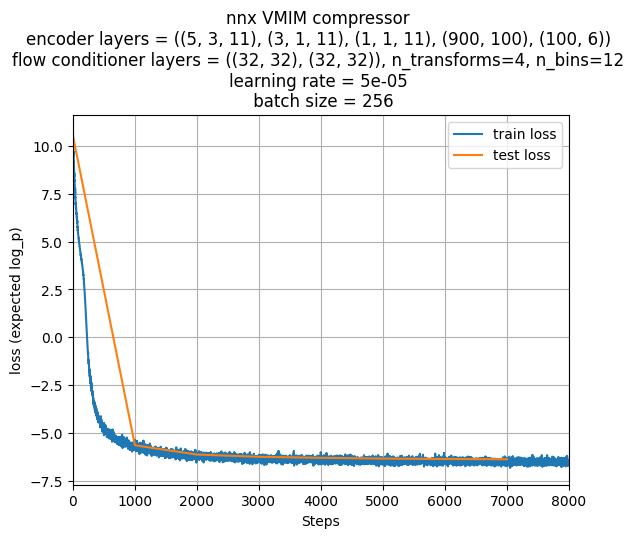

(7999, 6) (7999, 6)


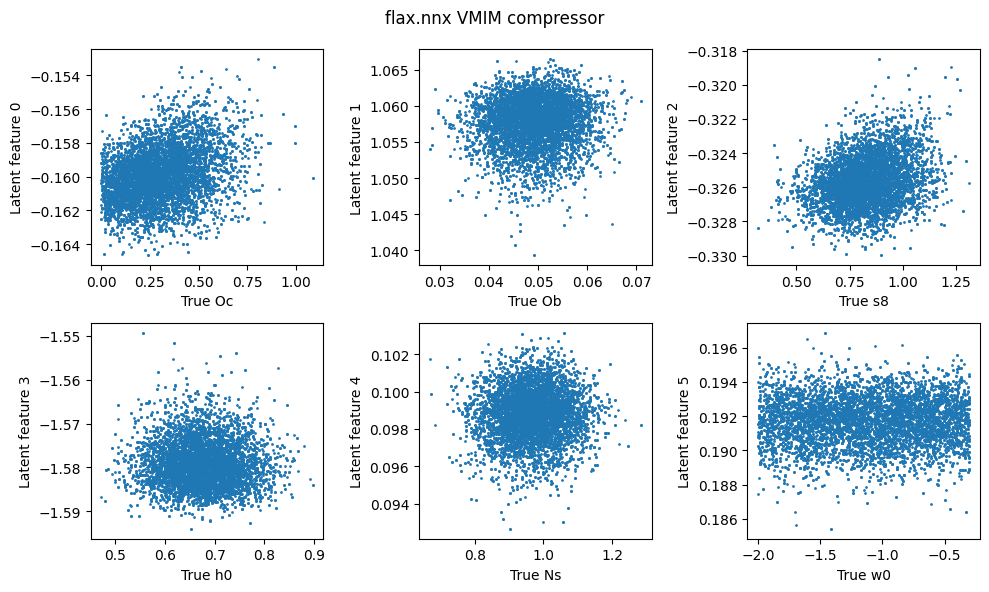

In [ ]:
# Training loss time series
fig, ax = plt.subplots()
ax.plot(range(STEPS), train_losses, label='train loss')
ax.plot(test_steps, test_losses, label='test loss')
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.xlabel("Steps")
plt.ylabel("loss (expected log_p)")
plt.title(f"nnx VMIM compressor \nencoder layers = {VMIM.encoder_layer_dims} \nflow conditioner layers = {VMIM.conditioner_hidden_dims}, n_transforms={VMIM.n_transforms}, n_bins={VMIM.n_bins} \nlearning rate = {LEARNING_RATE} \n batch size = {BATCH_SIZE}")
plt.savefig(f"plots/nnx_VMIM_loss_{STEPS}_steps.pdf")
plt.show()


# Truth vs Latent diagnostic scatter
gt = ground_truth = p
cd = compressed_data = VMIM.encode(x)
print(compressed_data.shape, p.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cp[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent feature {i}')

plt.suptitle("flax.nnx VMIM compressor")
plt.tight_layout()
plt.savefig(f"plots/nnx_VMIM_scatter_{STEPS}_steps.pdf")
plt.show()

10000 0 10
